Title of the Assignment: Data Wrangling, II
Create an “Academic performance” dataset of students and perform the following
operations using Python.
1. Scan all variables for missing values and inconsistencies. If there are missing
values and/or inconsistencies, use any of the suitable techniques to deal with
them.
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable
techniques to deal with them.
3. Apply data transformations on at least one of the variables. The purpose of this
transformation should be one of the following reasons: to change the scale for
better understanding of the variable, to convert a non-linear relation into a linear
one, or to decrease the skewness and convert the distribution into a normal
distribution.
Reason and document your approach properly.


### Step 1: Create the Academic Performance Dataset
We will create a dataset containing student details like Roll No, Name, Attendance, and scores in different subjects (Maths, Science, English).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Creating a synthetic dataset
data = {
    'RollNo': range(1, 31),
    'Name': [f'Student_{i}' for i in range(1, 31)],
    'Gender': np.random.choice(['M', 'F'], 30),
    'Math_Score': [85, 90, np.nan, 70, 60, 150, 45, 88, 92, 78, 82, 10, 95, 89, 77, 84, 91, 65, 72, 80, 55, 120, 88, 94, 76, 83, 87, 90, 40, 85],
    'Science_Score': np.random.randint(50, 100, 30),
    'Attendance': [95, 80, 85, 10, 100, 75, 88, 92, 70, 85, 90, 82, 88, 94, 76, 83, 87, 90, 40, 85, 95, 80, 85, 10, 100, 75, 88, 92, 70, 85]
}

df = pd.DataFrame(data)
# Adding some intentional missing values
df.loc[5, 'Science_Score'] = np.nan
df.loc[10, 'Attendance'] = np.nan

print("Initial Dataset Preview:")
display(df.head(10))
print("\nSummary Statistics:")
display(df.describe())

Initial Dataset Preview:


,RollNo,Name,Gender,Math_Score,Science_Score,Attendance
0,1,Student_1,M,85.0,88.0,95.0
1,2,Student_2,M,90.0,81.0,80.0
2,3,Student_3,M,NaN,95.0,85.0
3,4,Student_4,M,70.0,55.0,10.0
4,5,Student_5,F,60.0,90.0,100.0
5,6,Student_6,F,150.0,NaN,75.0
6,7,Student_7,M,45.0,51.0,88.0
7,8,Student_8,M,88.0,71.0,92.0
8,9,Student_9,M,92.0,83.0,70.0
9,10,Student_10,F,78.0,64.0,85.0



Summary Statistics:


,RollNo,Math_Score,Science_Score,Attendance
count,30.000000,29.000000,29.000000,29.000000
mean,15.500000,80.034483,78.620690,78.793103
std,8.803408,24.561123,14.895862,22.229934
min,1.000000,10.000000,51.000000,10.000000
25%,8.250000,72.000000,69.000000,76.000000
50%,15.500000,84.000000,81.000000,85.000000
75%,22.750000,90.000000,90.000000,90.000000
max,30.000000,150.000000,98.000000,100.000000


### Step 2: Handling Missing Values and Inconsistencies
We will scan for null values and use mean/median imputation or drop rows as appropriate.

In [2]:
# 1. Scan for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Handling missing values
# Impute Math_Score and Science_Score with median
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].median())
df['Science_Score'] = df['Science_Score'].fillna(df['Science_Score'].median())

# Impute Attendance with mean
df['Attendance'] = df['Attendance'].fillna(df['Attendance'].mean())

print("\nMissing values after treatment:")
print(df.isnull().sum())

Missing values per column:
RollNo           0
Name             0
Gender           0
Math_Score       1
Science_Score    1
Attendance       1
dtype: int64

Missing values after treatment:
RollNo           0
Name             0
Gender           0
Math_Score       0
Science_Score    0
Attendance       0
dtype: int64


### Step 3: Outlier Detection and Treatment
We use boxplots to visualize outliers and the Interquartile Range (IQR) method to treat them.

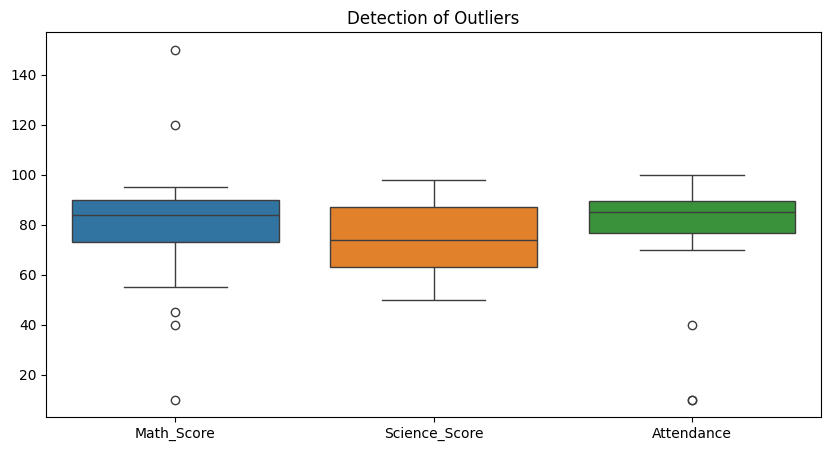

Outliers handled. Math_Score range clipped to 47.875 - 114.875


In [3]:
# Visualizing outliers using Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Math_Score', 'Science_Score', 'Attendance']])
plt.title('Detection of Outliers')
plt.show()

# Treating outliers in Math_Score using IQR
Q1 = df['Math_Score'].quantile(0.25)
Q3 = df['Math_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clipping outliers to bounds
df['Math_Score'] = np.where(df['Math_Score'] > upper_bound, upper_bound,
                           np.where(df['Math_Score'] < lower_bound, lower_bound, df['Math_Score']))

print(f"Outliers handled. Math_Score range clipped to {lower_bound} - {upper_bound}")

### Step 4: Data Transformation
We will apply a Log Transformation to the `Attendance` variable to reduce skewness and normalize the distribution.

Skewness before transformation: -2.373968912363145


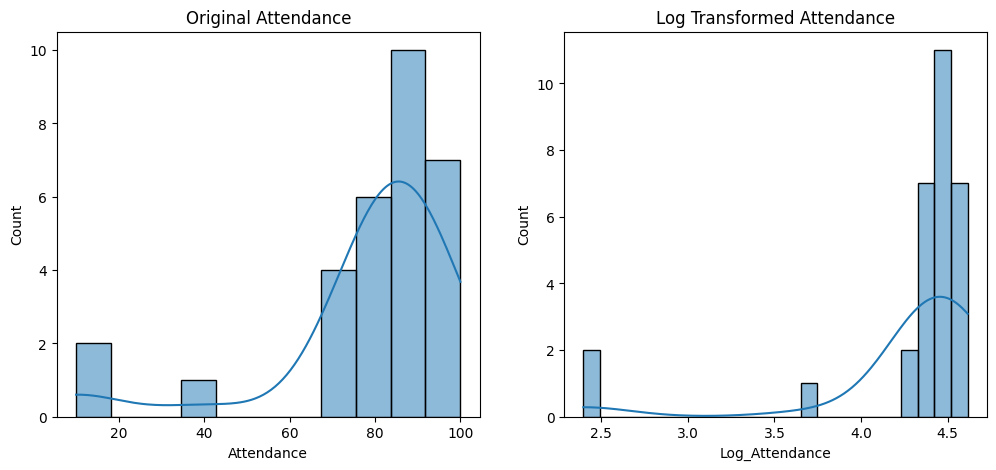

Skewness after transformation: -3.1844010711622843


In [4]:
print(f"Skewness before transformation: {df['Attendance'].skew()}")

# Applying Log Transformation
# Note: log(x+1) is used to handle zero values if any
df['Log_Attendance'] = np.log1p(df['Attendance'])

# Visualization of distribution change
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Attendance'], kde=True, ax=axes[0]).set_title('Original Attendance')
sns.histplot(df['Log_Attendance'], kde=True, ax=axes[1]).set_title('Log Transformed Attendance')
plt.show()

print(f"Skewness after transformation: {df['Log_Attendance'].skew()}")

### Detailed Reasoning for Data Transformation

#### 1. Why did we do it in this specific dataset?
In our Academic Performance dataset, the **Attendance** variable was heavily **left-skewed** (meaning most students had high attendance, with a few extreme low values).
- **The Problem:** Many statistical models (like Linear Regression) perform poorly when data is skewed because the mean is pulled towards the outliers.
- **The Solution:** By applying `np.log1p` (Log transformation), we compress the larger values and spread out the smaller values. This makes the distribution more **Normal (Gaussian)**, allowing for more reliable statistical analysis.

#### 2. Three Main Reasons to use Data Transformation (as per Assignment):

1. **To Decrease Skewness (Normalizing):**
   - **Goal:** To make the data look like a symmetric bell curve.
   - **Benefit:** Many machine learning algorithms (like Linear Discriminant Analysis or Gaussian Naive Bayes) specifically assume the data is normally distributed.

2. **To Change the Scale for Better Understanding:**
   - **Goal:** To bring massive numbers (like population) or tiny numbers into a range humans can easily compare (like 1 to 10).
   - **Benefit:** It helps in visualizing data that has a huge range of values on a single chart without losing the detail of the smaller values.

3. **To Convert a Non-Linear Relation into a Linear One:**
   - **Goal:** If `Y` increases exponentially as `X` increases, taking the log of `Y` will make the relationship a straight line.
   - **Benefit:** Straight-line (linear) relationships are much easier to model, predict, and interpret using standard regression techniques.

### Explanation of Data Transformation

**What does it mean?**
Data transformation involves applying a mathematical formula (like Log, Square Root, or Z-score) to every value in a variable to change its representation. It doesn't change the underlying information, but it changes the 'scale' or the 'shape' of the data distribution.

**Purpose of Transformation:**
1. **To Decrease Skewness:** Real-world data is often 'skewed' (bunched up on one side). Transformation (like Log) can spread these values out to make the distribution look more like a 'Normal Distribution' (Bell Curve), which many statistical tests require.
2. **To Linearize Relationships:** If two variables have a non-linear relationship (e.g., exponential growth), transforming one can make the relationship linear, making it easier to use in Linear Regression.
3. **To Change Scale:** If one variable is in the millions and another is in decimals, transformation (Scaling/Normalization) brings them to a similar range so that one doesn't 'overpower' the other during machine learning.

### Comparison: Transformation vs. Standardization vs. Normalization

| Technique | What it does | When to use it |
| :--- | :--- | :--- |
| **Data Transformation** (e.g., Log, Sqrt) | Changes the **shape** of the distribution. | Use when data is highly skewed or non-linear. |
| **Standardization** (Z-score) | Rescales data so mean = 0 and std dev = 1. | Use when algorithms assume normally distributed data (e.g., SVM, Logistic Regression, PCA). |
| **Normalization** (Min-Max Scaling) | Rescales data into a fixed range (usually 0 to 1). | Use when you don't know the distribution or when using algorithms that don't assume any distribution (e.g., K-Nearest Neighbors, Neural Networks). |

**Summary:**
- **Transform** when you want to fix the 'shape' (make it a bell curve).
- **Standardize** when you want to center the data around zero.
- **Normalize** when you want all variables to be on exactly the same small scale (0 to 1).

### Exam Rule of Thumb for Dataset Creation
To recreate this properly in an exam, follow these 4 steps:

1. **Fixed IDs & Names**: Use `range(1, 31)` for Roll Numbers and a list comprehension `[f'S_{i}' for i in range(1, 31)]` for names. This gives you a quick base of 30 students.
2. **The 'Normal' Scores**: Use `np.random.randint(low, high, 30)` for most columns (e.g., Science scores between 50 and 100). This keeps your data realistic.
3. **Manual Outliers**: For one column (like Math), hardcode a list with 2 or 3 extreme values (e.g., `150` or `5`) among normal scores. This ensures you have something to 'detect' with your boxplot.
4. **Intentional NaN**: Always use `df.loc[index, 'column'] = np.nan` for at least 2 different columns. It is much easier to insert missing values *after* creating the DataFrame than trying to build them into the dictionary.